<a href="https://colab.research.google.com/github/ellen-ying/NMA2026/blob/main/projects/mouse_rl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title Install dependencies
!pip install gymnasium stable-baselines3[extra] matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 116.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 20.0 MB/s eta 0:00:00


In [ ]:
# @title Imports
# Standard Library Imports
import os
import time

# Third-Party Library Imports
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

# Specific Submodule Imports
from gymnasium import spaces
from IPython.display import clear_output, display, HTML
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Simple IBL without contrast

In [ ]:
class IBL_simple(gym.Env):
    """
    An reward-based leearning task environment compatible with the Gymnasium API.

    The agent's goal is to choose the action (L/R) opposite to the presented stimulus.

    Observation:
        A numpy array of size (1,), containing the current observation.
        Stimuli are encoded as integers (0 for 'L', 1 for 'R').

    Actions:
        0: 'L'
        1: 'R'

    Reward:
        +1 for choosing the action opposite to the current stimulus.
        0 for choosing the same action as the current stimulus.
    """
    ACTIONS = {0: 'L', 1: 'R'} # Flipped for easier indexing

    def __init__(self,
                 episode_steps=32,
                 stimuli_choices=2,
                 right_prob=0.5,
                 seed=None):
        """
        Args:
            episode_steps (int): The total number of trials in an episode.
            stimuli_choices (int): The number of unique stimuli (e.g., 2 for 'L' and 'R').
            seed (int, optional): Seed for the random number generator. Defaults to None.
        """
        super().__init__()

        self.episode_steps = episode_steps
        self.num_stimuli = stimuli_choices
        self.probs = [1 - right_prob, right_prob]

        # --- Define action and observation spaces ---
        # Action space: 0 for 'left', 1 for 'right'
        self.action_space = spaces.Discrete(len(self.ACTIONS))

        # Observation space: The sequence of stimuli seen so far.
        # We use a Box space for easy extension later.
        self.observation_space = spaces.Box(
            low=0, # ignore the stimulus strength for now
            high=1,
            shape=(1,),
            dtype=np.float32
        )

        self._stimuli = np.zeros(self.episode_steps, dtype=np.float32)
        self._action_history = []
        self._current_step = 0

        # Seed the random number generator
        if seed is not None:
            self._np_random, _ = gym.utils.seeding.np_random(seed)
        else:
            self._np_random = np.random.RandomState()


    def reset(self, seed=None, options=None):
        """Resets the environment to the beginning of a new episode."""
        super().reset(seed=seed)

        self._current_step = 0
        self._action_history = []

        # Generate a new sequence of stimuli for the episode
        self._stimuli = self._np_random.choice(self.num_stimuli,
                                               self.episode_steps,
                                               self.probs).astype(np.float32)

        observation = self._get_observation()
        info = self._get_info()

        return observation, info

    def step(self, action: int):
        """Processes one step of the environment."""
        if self._stimuli[self._current_step] != action:
            # left stimulus reqruies right action and vice versa
            reward = 1.0
        else:
            reward = 0.0

        self._action_history.append(self.ACTIONS[action])
        self._current_step += 1

        # Check for episode termination
        terminated = self._current_step >= self.episode_steps
        truncated = False # Not using truncation here

        observation = self._get_observation()
        info = self._get_info()

        return observation, reward, terminated, truncated, info

    def _get_observation(self):
        """Returns the current observation for the agent."""
        if self._current_step >= self.episode_steps:
            return None
        else:
            obs = np.array([self._stimuli[self._current_step]])
            return obs.astype(np.float32)

    def _get_info(self):
        """Returns auxiliary diagnostic information."""
        return {
            "step": self._current_step,
            "stimuli_sequence": self._stimuli
        }

    def render(self, mode='human'):
        """Renders the current state of the environment for visualization."""
        stimuli_str = "".join(['L' if s == 0 else 'R' for s in self._stimuli])
        actions_str = "".join(self._action_history)

        html_content = (
            f'Environment (IBL) | Step: {self._current_step}/{self.episode_steps}<br>'
            f'Stimuli: {stimuli_str}<br>'
            f'Actions: {actions_str}'
        )
        return HTML(html_content)

In [ ]:
# Example of how to create and test the environment
print("Testing the IBL Environment...")

# Create the environment
env = IBL_simple(episode_steps=10, right_prob=0.8)

# Reset the environment
obs, info = env.reset()
#print("Stimulus sequence: " + " ".join(map(str, info["stimuli_sequence"].tolist())))
print(f"Initial Observation Shape: {obs.shape}")
print(f"Action Space: {env.action_space}")

terminated = False
total_reward = 0
step_count = 0

# Run one episode with random actions
while not terminated:
    action = env.action_space.sample() # Take a random action
    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward
    step_count += 1

    print(f"Step {step_count}: Action={IBL.ACTIONS[action]}, Reward={reward:.1f}")

print("\nEpisode Finished.")
print(f"Total Steps: {step_count}")
print(f"Total Reward: {total_reward}")

# Display final state
display(env.render())

Testing the IBL Environment...
Initial Observation Shape: (1,)
Action Space: Discrete(2)
Step 1: Action=R, Reward=1.0
Step 2: Action=L, Reward=0.0
Step 3: Action=L, Reward=0.0
Step 4: Action=L, Reward=0.0
Step 5: Action=R, Reward=0.0
Step 6: Action=L, Reward=1.0
Step 7: Action=L, Reward=0.0
Step 8: Action=R, Reward=0.0
Step 9: Action=L, Reward=1.0
Step 10: Action=R, Reward=0.0

Episode Finished.
Total Steps: 10
Total Reward: 3.0


## Random Agent

In [ ]:
def run_random_agent_episode(env, render=True):
    """
    Runs a single episode in the given Gymnasium environment using random actions.

    Args:
        env (gym.Env): The Gymnasium environment to run.
        render (bool): If True, renders the environment state at each step.

    Returns:
        tuple: A tuple containing the total reward and the number of steps.
    """
    print("🚀 Starting new episode with Random Agent...")
    total_reward = 0
    obs, info = env.reset()

    terminated = False
    while not terminated:
        # The core of the random agent: sample a random action!
        action = env.action_space.sample()

        # Take the action in the environment
        obs, reward, terminated, truncated, info = env.step(action)

        total_reward += reward

        if render:
            clear_output(wait=True)
            display(env.render())
            time.sleep(0.1) # Pause for visibility

    print(f"🏁 Episode finished in {info['step']} steps.")
    print(f"🏆 Total Reward: {total_reward}")
    return total_reward, info['step']

# --- Let's run it! ---
# Create the IBL environment
IBL_env = IBL_simple(episode_steps=32, right_prob = 0.8)

# Run one full episode with our random agent
run_random_agent_episode(IBL_env, render=True)

🏁 Episode finished in 32 steps.
🏆 Total Reward: 14.0


(14.0, 32)

Running 1000 episodes with a Random Agent...
Episode: 100/1000 | Return: 15.00 | Total Steps: 3200
Episode: 200/1000 | Return: 16.00 | Total Steps: 6400
Episode: 300/1000 | Return: 17.00 | Total Steps: 9600
Episode: 400/1000 | Return: 16.00 | Total Steps: 12800
Episode: 500/1000 | Return: 12.00 | Total Steps: 16000
Episode: 600/1000 | Return: 14.00 | Total Steps: 19200
Episode: 700/1000 | Return: 14.00 | Total Steps: 22400
Episode: 800/1000 | Return: 13.00 | Total Steps: 25600
Episode: 900/1000 | Return: 20.00 | Total Steps: 28800
Episode: 1000/1000 | Return: 9.00 | Total Steps: 32000
✅ All episodes completed.
Total steps taken: 32000
Average return per episode: 16.02


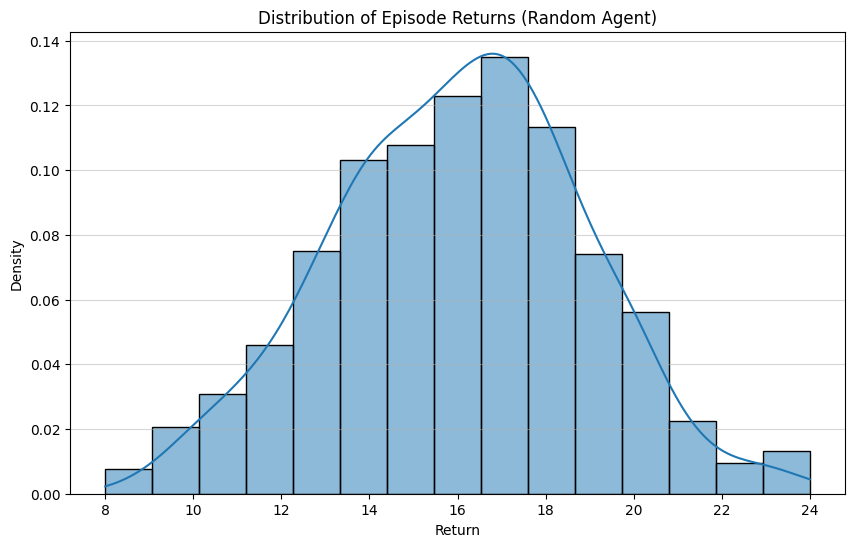

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


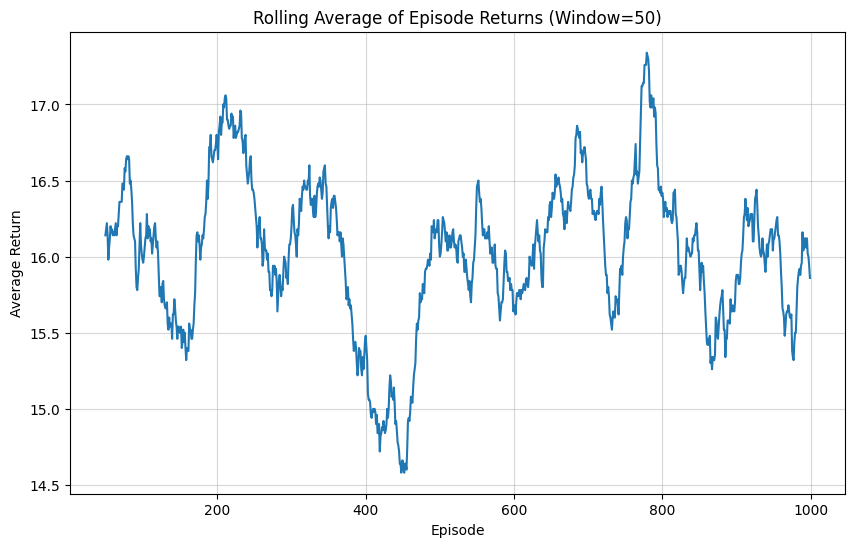

In [ ]:
# Training parameters
n_episodes = 1000
all_returns = []
total_steps = 0

print(f"Running {n_episodes} episodes with a Random Agent...")

# --- Main Loop ---
for episode in range(n_episodes):
    episode_return = 0

    # Reset the environment for a new episode
    observation, info = IBL_env.reset()

    terminated = False
    truncated = False

    # Run the episode
    while not terminated and not truncated:
        # 1. Select a random action (our "Random Agent")
        action = IBL_env.action_space.sample()

        # 2. Step the environment with the action
        observation, reward, terminated, truncated, info = IBL_env.step(action)

        # 3. Book-keeping
        episode_return += reward
        total_steps += 1

    # --- End of Episode ---
    all_returns.append(episode_return)

    # Log results every 100 episodes to avoid too much output
    if (episode + 1) % 100 == 0:
        print(f"Episode: {episode + 1}/{n_episodes} | Return: {episode_return:.2f} | Total Steps: {total_steps}")


#clear_output(wait=True)
print("✅ All episodes completed.")
print(f"Total steps taken: {total_steps}")
print(f"Average return per episode: {np.mean(all_returns):.2f}")


# --- Final Plot ---
# Histogram of all returns
plt.figure(figsize=(10, 6))
sns.histplot(all_returns, stat="density", kde=True, bins=15)
plt.title('Distribution of Episode Returns (Random Agent)')
plt.xlabel('Return')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.5)
plt.show()

# Also show a rolling average of returns to see if there was any learning
# (There won't be for a random agent, but this is good practice)
rolling_avg = pd.Series(all_returns).rolling(window=50).mean()
plt.figure(figsize=(10, 6))
plt.plot(rolling_avg)
plt.title('Rolling Average of Episode Returns (Window=50)')
plt.xlabel('Episode')
plt.ylabel('Average Return')
plt.grid(True, alpha=0.5)
plt.show()

## Create a DQN agent

In [ ]:
log_dir = "./tmp/gym/"
os.makedirs(log_dir, exist_ok=True)
env = IBL_simple(right_prob=0.8, episode_steps=32)
monitored_env = Monitor(env, log_dir)

In [ ]:
policy_kwargs = dict(
    net_arch=[50, 50]  # Two hidden layers with 50 neurons each
)

In [ ]:
# - 'MlpPolicy': Use a standard Multi-Layer Perceptron policy.
# - env: The environment instance for the agent to learn in.
# - policy_kwargs: Our custom network architecture.
# - learning_rate: The step size for the optimizer.
# - buffer_size: The size of the replay buffer.
# - exploration_initial_eps/exploration_final_eps: To mimic the original
#   constant epsilon=0.5, we set both to 0.5. For real training, you would
#   typically anneal this from 1.0 down to a small value.
# - verbose=1: To print training information.
# - tensorboard_log: Directory for saving TensorBoard logs.
#
agent = DQN(
    policy='MlpPolicy',
    env=monitored_env,
    policy_kwargs=policy_kwargs,
    gamma=0,
    learning_rate=1e-3,
    buffer_size=10000,
    learning_starts=100, # Number of steps to collect before training starts
    batch_size=32,
    train_freq=(1, "step"),
    target_update_interval=250,
    exploration_final_eps=0.01,
    verbose=1,
    tensorboard_log="./nback_dqn_tensorboard/"
)

Using cuda device
Wrapping the env in a DummyVecEnv.


In [ ]:
n_episodes = 500
episode_steps = 32
total_timesteps = n_episodes * episode_steps

print(f"🚀 Starting training for {total_timesteps} timesteps...")
agent.learn(total_timesteps=total_timesteps)
print("✅ Training complete.")

In [ ]:
# @title Plotter function
def plot_training_results(log_folder, title='Learning Curve'):
    """
    Plots the training results from a Monitor log file.
    :param log_folder: (str) the save location of the results to plot
    :param title: (str) the title of the task to plot
    """
    x, y = ts2xy(load_results(log_folder), 'timesteps')

    # The reward in our env is max 32 (1 per step)
    # We can calculate accuracy from this
    y_acc = (np.array(y) / 32.0) * 100

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Plot 1: Episode Rewards
    ax1.plot(x, y, color='blue')
    ax1.set_title(title)
    ax1.set_ylabel('Episode Reward')
    ax1.grid(True)

    # Plot a rolling average for rewards
    y_rolling = pd.Series(y).rolling(50).mean()
    ax1.plot(x, y_rolling, color='red', linewidth=2, label='Rolling Avg (50 episodes)')
    ax1.legend()

    # Plot 2: Episode Accuracy
    ax2.plot(x, y_acc, color='green')
    ax2.set_ylabel('Episode Accuracy (%)')
    ax2.set_xlabel('Timesteps')
    ax2.grid(True)

    # Plot a rolling average for accuracy
    y_acc_rolling = pd.Series(y_acc).rolling(50).mean()
    ax2.plot(x, y_acc_rolling, color='orange', linewidth=2, label='Rolling Avg (50 episodes)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

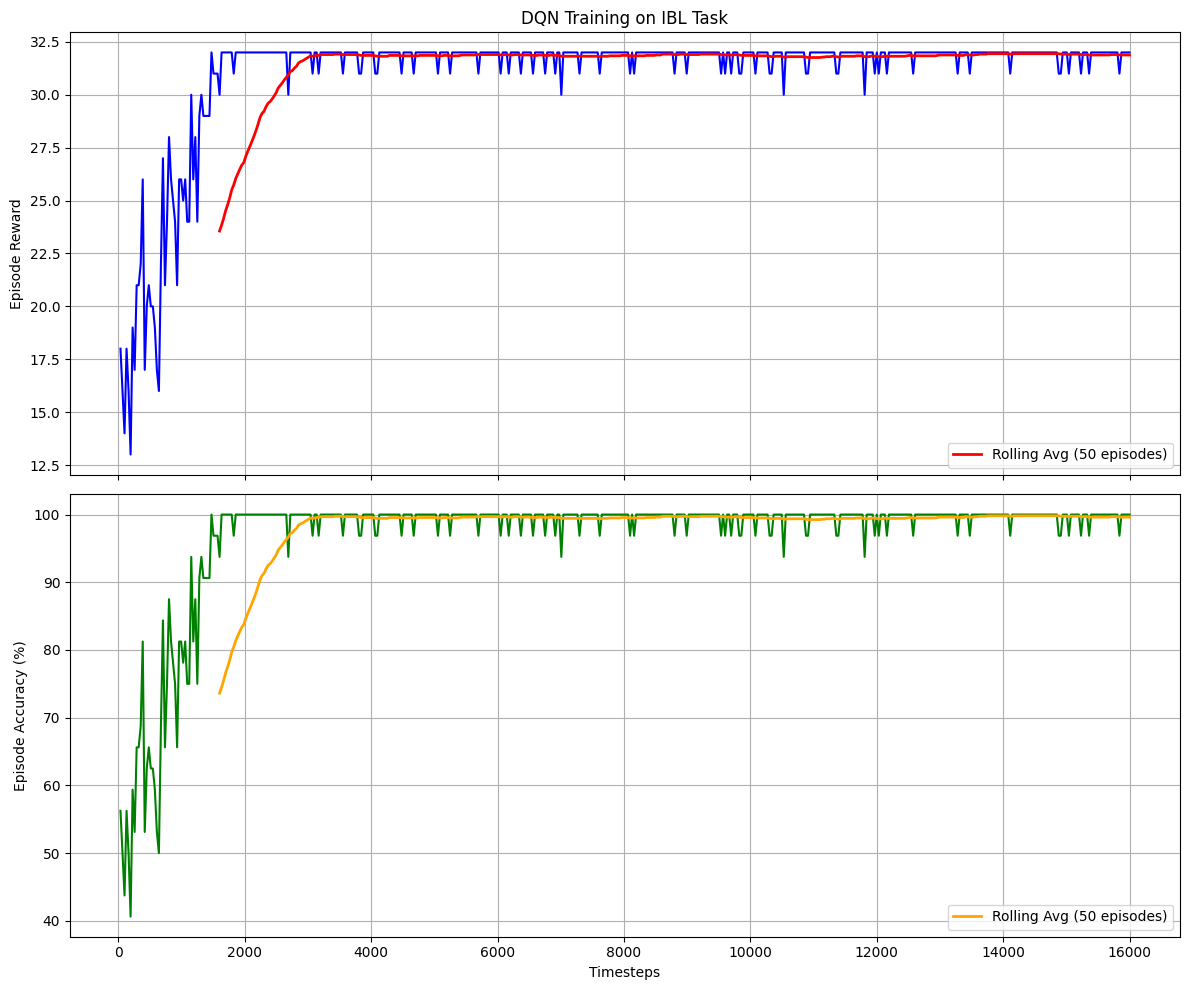

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
plot_training_results(log_dir, "DQN Training on IBL Task")


## Full IBL environment

In [ ]:
class IBL(gym.Env):
    """
    An Imitation Learning task environment compatible with the Gymnasium API.

    The agent's goal is to choose the action (L/R) opposite to the presented stimulus.

    Observation:
        A numpy array of size (episode_steps,), containing the stimuli
        presented up to the current step, padded with zeros for future steps.
        Stimuli are encoded as integers (0 for 'L', 1 for 'R').

    Actions:
        0: 'L'
        1: 'R'

    Reward:
        +1 for choosing the action opposite to the current stimulus.
        0 for choosing the same action as the current stimulus.
    """
    ACTIONS = {0: 'L', 1: 'R'} # Flipped for easier indexing

    def __init__(self,
                 episode_steps=32,
                 stimuli_choices=2,
                 right_prob=0.5,
                 seed=None):
        """
        Args:
            episode_steps (int): The total number of trials in an episode.
            stimuli_choices (int): The number of unique stimuli (e.g., 2 for 'L' and 'R').
            seed (int, optional): Seed for the random number generator. Defaults to None.
        """
        super().__init__()

        self.episode_steps = episode_steps
        self.num_stimuli = stimuli_choices
        self.probs = [1 - right_prob, right_prob]

        # --- Define action and observation spaces ---
        # Action space: 0 for 'left', 1 for 'right'
        self.action_space = spaces.Discrete(len(self.ACTIONS))

        # Observation space: The sequence of stimuli seen so far.
        # We use a Box space, where each element is an integer representing a stimulus.
        # The shape is (2,) for [stimulus_position, contrast_strength]
        self.observation_space = spaces.Box(
            low=np.array([0,0]),
            high=np.array([1,1]),
            shape=(2,),
            dtype=np.float32
        )

        # _stimuli will now store [stimulus_position, contrast_strength] for each step
        self._stimuli = np.zeros((self.episode_steps, 2), dtype=np.float32)
        self._action_history = []
        self._current_step = 0

        # Seed the random number generator
        if seed is not None:
            self._np_random, _ = gym.utils.seeding.np_random(seed)
        else:
            self._np_random = np.random.RandomState()


    def reset(self, seed=None, options=None):
        """Resets the environment to the beginning of a new episode."""
        super().reset(seed=seed)

        self._current_step = 0
        self._action_history = []

        # Generate a new sequence of stimuli for the episode
        stimuli_position = self._np_random.choice(self.num_stimuli,
                                               self.episode_steps,
                                               p=self.probs).astype(np.float32)

        # Define the contrast levels as requested
        contrast_levels = np.array([0, 0.0625, 0.125, 0.25, 1], dtype=np.float32)
        # Randomly sample contrast_strength for each step
        contrast_strength = self._np_random.choice(contrast_levels,
                                                    self.episode_steps).astype(np.float32)

        # Combine stimuli_position and contrast_strength into self._stimuli
        # Each row will be [stimulus_position, contrast_strength]
        self._stimuli = np.stack((stimuli_position, contrast_strength), axis=-1)

        observation = self._get_observation()
        info = self._get_info()

        return observation, info

    def step(self, action: int):
        """Processes one step of the environment."""
        # Compare the action with the stimulus position (first element of the stimulus pair)
        if self._stimuli[self._current_step, 0] != action:
            # left stimulus requires right action and vice versa
            reward = 1.0
        else:
            reward = 0.0

        self._action_history.append(self.ACTIONS[action])
        self._current_step += 1

        # Check for episode termination
        terminated = self._current_step >= self.episode_steps
        truncated = False # Not using truncation here

        observation = self._get_observation()
        info = self._get_info()

        return observation, reward, terminated, truncated, info

    def _get_observation(self):
        """Returns the current observation for the agent."""
        if self._current_step >= self.episode_steps:
            return None
        else:
            # Return the current stimulus and its contrast as a (2,) array
            # The observation space expects shape (2,)
            obs = np.array(self._stimuli[self._current_step])
            return obs.astype(np.float32)

    def _get_info(self):
        """Returns auxiliary diagnostic information."""
        return {
            "step": self._current_step,
            "stimuli_sequence": self._stimuli[:, 0],
            "contrast_strength": self._stimuli[:, 1]
        }

    def render(self, mode='human'):
        """Renders the current state of the environment for visualization."""
        # Use the first column (stimulus position) for rendering
        stimuli_str = "".join(['L' if s == 0 else 'R' for s in self._stimuli[:, 0]])
        actions_str = "".join(self._action_history)

        html_content = (
            f'Environment (IBL) | Step: {self._current_step}/{self.episode_steps}<br>'
            f'Stimuli: {stimuli_str}<br>'
            f'Actions: {actions_str}'
        )
        return HTML(html_content)


In [ ]:
# Example of how to create and test the environment
print("Testing the IBL Environment...")

# Create the environment
env = IBL(episode_steps=10, right_prob=0.8)

# Reset the environment
obs, info = env.reset()
#print("Stimulus sequence: " + " ".join(map(str, info["stimuli_sequence"].tolist())))
print(f"Initial Observation Shape: {obs.shape}")
print(f"Action Space: {env.action_space}")

terminated = False
total_reward = 0
step_count = 0

# Run one episode with random actions
while not terminated:
    print(f"Step {step_count}: Stimulus={obs[0]}, Contrast={obs[1]}")
    action = env.action_space.sample() # Take a random action
    obs, reward, terminated, truncated, info = env.step(action)

    total_reward += reward
    step_count += 1

    print(f"Action={IBL.ACTIONS[action]}, Reward={reward:.1f}")

print("\nEpisode Finished.")
print(f"Total Steps: {step_count}")
print(f"Total Reward: {total_reward}")

Testing the IBL Environment...
Initial Observation Shape: (2,)
Action Space: Discrete(2)
Step 0: Stimulus=1.0, Contrast=0.0
Action=L, Reward=1.0
Step 1: Stimulus=1.0, Contrast=1.0
Action=L, Reward=1.0
Step 2: Stimulus=1.0, Contrast=0.0
Action=R, Reward=0.0
Step 3: Stimulus=0.0, Contrast=0.125
Action=R, Reward=1.0
Step 4: Stimulus=1.0, Contrast=1.0
Action=L, Reward=1.0
Step 5: Stimulus=1.0, Contrast=0.125
Action=L, Reward=1.0
Step 6: Stimulus=1.0, Contrast=0.0625
Action=L, Reward=1.0
Step 7: Stimulus=1.0, Contrast=0.125
Action=L, Reward=1.0
Step 8: Stimulus=1.0, Contrast=0.125
Action=L, Reward=1.0
Step 9: Stimulus=1.0, Contrast=1.0
Action=R, Reward=0.0

Episode Finished.
Total Steps: 10
Total Reward: 8.0


In [ ]:
log_dir = "./tmp/gym/"
os.makedirs(log_dir, exist_ok=True)
env = IBL_simple(right_prob=0.8, episode_steps=32)
monitored_env = Monitor(env, log_dir)

In [ ]:
#@title New DQN agent
policy_kwargs = dict(
    net_arch=[50, 50]  # Two hidden layers with 50 neurons each
)

# - 'MlpPolicy': Use a standard Multi-Layer Perceptron policy.
# - env: The environment instance for the agent to learn in.
# - policy_kwargs: Our custom network architecture.
# - learning_rate: The step size for the optimizer.
# - buffer_size: The size of the replay buffer.
# - exploration_initial_eps/exploration_final_eps: To mimic the original
#   constant epsilon=0.5, we set both to 0.5. For real training, you would
#   typically anneal this from 1.0 down to a small value.
# - verbose=1: To print training information.
# - tensorboard_log: Directory for saving TensorBoard logs.
#
agent = DQN(
    policy='MlpPolicy',
    env=monitored_env,
    policy_kwargs=policy_kwargs,
    gamma=0,
    learning_rate=1e-3,
    buffer_size=10000,
    learning_starts=100, # Number of steps to collect before training starts
    batch_size=32,
    train_freq=(1, "step"),
    target_update_interval=250,
    exploration_final_eps=0.01,
    verbose=1,
    tensorboard_log="./nback_dqn_tensorboard/"
)

Using cuda device
Wrapping the env in a DummyVecEnv.


In [ ]:
n_episodes = 500
episode_steps = 32
total_timesteps = n_episodes * episode_steps

print(f"🚀 Starting training for {total_timesteps} timesteps...")
agent.learn(total_timesteps=total_timesteps)
print("✅ Training complete.")

🚀 Starting training for 16000 timesteps...
Logging to ./nback_dqn_tensorboard/DQN_4
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 32       |
|    ep_rew_mean      | 16.8     |
|    exploration_rate | 0.921    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1354     |
|    time_elapsed     | 0        |
|    total_timesteps  | 128      |
| train/              |          |
|    learning_rate    | 0.001    |
|    loss             | 0.11     |
|    n_updates        | 27       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 32       |
|    ep_rew_mean      | 17.2     |
|    exploration_rate | 0.842    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 361      |
|    time_elapsed     | 0        |
|    total_timesteps  | 256      |
| train/              |          |
|    l

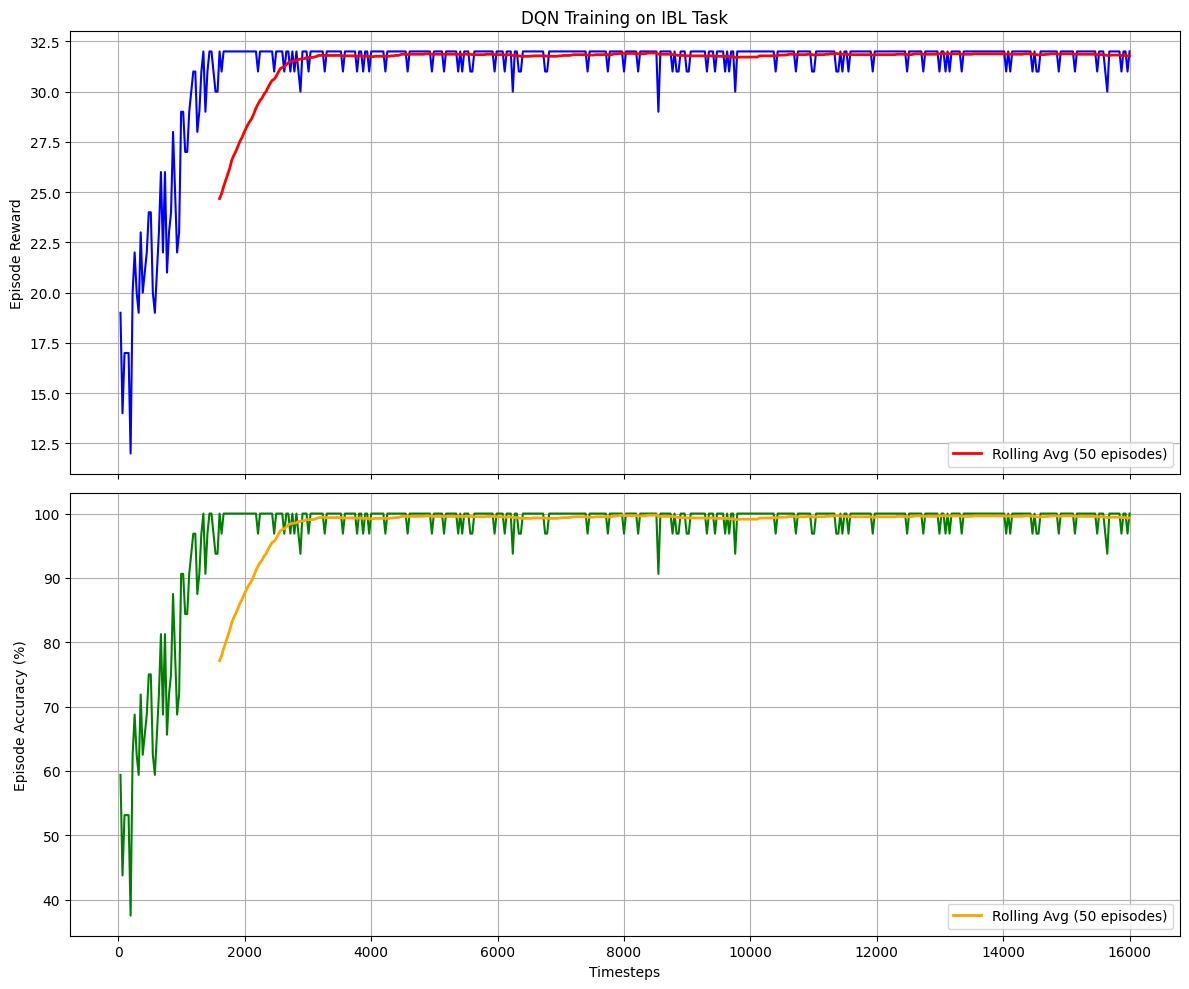

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
plot_training_results(log_dir, "DQN Training on IBL Task")